Project Setup Block 

In [1]:
print('Bismillah')

Bismillah


In [2]:
# ==========================================
# 1. PROJECT SETUP & CONFIGURATION
# ==========================================

# Standard library imports
import warnings
import gc # Garbage collector for memory management

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Environment Configuration
# ------------------------------------------
# Suppress warnings to keep the notebook clean for GitHub and stakeholders
warnings.filterwarnings('ignore')

# ------------------------------------------
# Pandas Display Options
# ------------------------------------------
# Ensure we can see all columns and a reasonable number of rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Format floats to 3 decimal places to avoid scientific notation (crucial for financial data)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# ------------------------------------------
# Visualization Defaults
# ------------------------------------------
# Set a clean, modern, and professional aesthetic for client presentations
sns.set_theme(style="whitegrid", palette="muted")

# Update matplotlib global parameters
plt.rcParams.update({
    'figure.figsize': (12, 6),      # Default wide aspect ratio suitable for time-series
    'axes.titlesize': 16,           # Clear, readable title sizes
    'axes.titleweight': 'bold',
    'axes.labelsize': 14,           # Axis label sizes
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 100,              # High resolution for GitHub rendering
    'axes.spines.top': False,       # Remove top/right borders for a cleaner look
    'axes.spines.right': False
})

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Professional Data Science Environment Setup Complete.")

✅ Professional Data Science Environment Setup Complete.


BLOCK 2

In [3]:
# ==========================================
# 2. DATA LOADING & MEMORY OPTIMIZATION (FINAL)
# ==========================================

import os
import time
import pandas as pd
import gc

# Define file paths using relative directories
RAW_DATA_PATH = os.path.join('..', 'data', 'raw', 'online_retail_II.xlsx')
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed', 'online_retail.parquet')

def load_data():
    """
    Loads data from Parquet if available (fast), otherwise loads from Excel (slow),
    defensively fixes all mixed data types, and saves a Parquet checkpoint.
    """
    if os.path.exists(PROCESSED_DATA_PATH):
        print("✅ Found optimized Parquet file. Loading...")
        start_time = time.time()
        df = pd.read_parquet(PROCESSED_DATA_PATH)
        print(f"⏱️ Loaded in {time.time() - start_time:.2f} seconds.")
    else:
        print("⚠️ Optimized Parquet not found. Loading from raw Excel (this may take a few minutes)...")
        start_time = time.time()
        
        # Load both sheets
        df_sheet1 = pd.read_excel(RAW_DATA_PATH, sheet_name='Year 2009-2010')
        df_sheet2 = pd.read_excel(RAW_DATA_PATH, sheet_name='Year 2010-2011')
        
        # Concatenate the two years of data vertically
        df = pd.concat([df_sheet1, df_sheet2], ignore_index=True)
        print(f"⏱️ Loaded from Excel in {time.time() - start_time:.2f} seconds.")
        
        print("🔧 Defensively casting all text/ID columns to strings to prevent Parquet crashes...")
        # Force all non-math columns to strings. 
        # (Note: Customer ID has NaNs, which will temporarily become the string "nan". We will clean this in Phase 3).
        text_columns = ['Invoice', 'StockCode', 'Description', 'Customer ID', 'Country']
        for col in text_columns:
            df[col] = df[col].astype(str)
        
        print("💾 Saving optimized Parquet checkpoint for future runs...")
        df.to_parquet(PROCESSED_DATA_PATH, index=False)
        
        # Free up memory
        del df_sheet1, df_sheet2
        gc.collect() 
        
    return df

# Execute the loading function
df_raw = load_data()

# Inspect the true memory footprint
print("\n--- Dataset Memory Profile ---")
df_raw.info(memory_usage='deep')

✅ Found optimized Parquet file. Loading...
⏱️ Loaded in 1.28 seconds.

--- Dataset Memory Profile ---
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   str           
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 122.9 MB


phase 3


In [4]:
# ==========================================
# 3. INITIAL INSPECTION
# ==========================================

print("--- First 5 Rows ---")
display(df_raw.head())

print("\n--- Last 5 Rows ---")
display(df_raw.tail())

print("\n--- Numerical Summary ---")
# We only describe numeric columns here. We round to 3 decimal places for readability.
display(df_raw.describe().T.round(3))

print("\n--- Date Range ---")
print(f"First Transaction: {df_raw['InvoiceDate'].min()}")
print(f"Last Transaction:  {df_raw['InvoiceDate'].max()}")

--- First 5 Rows ---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,13085.0,United Kingdom



--- Last 5 Rows ---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.100,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.150,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.150,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.950,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.000,12680.0,France



--- Numerical Summary ---


,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.000,9.939,-80995.000,1.000,3.000,10.000,80995.000,172.706
InvoiceDate,1067371,2011-01-02 21:13:55.394029,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.000,4.649,-53594.360,1.250,2.100,4.150,38970.000,123.553



--- Date Range ---
First Transaction: 2009-12-01 07:45:00
Last Transaction:  2011-12-09 12:50:00


In [5]:
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'], errors='coerce')  # Ensure datetime format

In [6]:
df_raw.describe()

,Quantity,InvoiceDate,Price
count,1067371.000,1067371,1067371.000
mean,9.939,2011-01-02 21:13:55.394029,4.649
min,-80995.000,2009-12-01 07:45:00,-53594.360
25%,1.000,2010-07-09 09:46:00,1.250
50%,3.000,2010-12-07 15:28:00,2.100
75%,10.000,2011-07-22 10:23:00,4.150
max,80995.000,2011-12-09 12:50:00,38970.000
std,172.706,NaN,123.553


Phase 4


In [7]:
# ==========================================
# 4. DATA QUALITY ASSESSMENT
# ==========================================

print("--- 1. Missing Values Count ---")
missing_data = df_raw.isnull().sum()
display(missing_data[missing_data > 0].to_frame(name='Missing Rows'))

print("\n--- 2. Duplicate Records ---")
duplicate_count = df_raw.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df_raw)) * 100
print(f"Total Duplicate Rows: {duplicate_count:,} ({duplicate_percentage:.2f}%)")

print("\n--- 3. Structural Anomalies ---")
# Count how many rows have negative quantities
negative_qty_count = (df_raw['Quantity'] < 0).sum()
print(f"Rows with Negative Quantity (Likely Returns): {negative_qty_count:,}")

# Count how many rows have zero or negative prices
invalid_price_count = (df_raw['Price'] <= 0).sum()
print(f"Rows with Price <= 0 (Free items or Adjustments): {invalid_price_count:,}")

print("\n--- 4. Inspecting the 'C' (Cancelled) Invoices ---")
# Filter for invoices that start with 'C'
cancelled_invoices = df_raw[df_raw['Invoice'].str.startswith('C', na=False)]
print(f"Total Cancelled Invoices: {len(cancelled_invoices):,}")

# Let's look at the top 3 cancelled transactions to understand their structure
display(cancelled_invoices.head(3))

--- 1. Missing Values Count ---


,Missing Rows
Description,4382
Customer ID,243007



--- 2. Duplicate Records ---
Total Duplicate Rows: 34,335 (3.22%)

--- 3. Structural Anomalies ---
Rows with Negative Quantity (Likely Returns): 22,950
Rows with Price <= 0 (Free items or Adjustments): 6,207

--- 4. Inspecting the 'C' (Cancelled) Invoices ---
Total Cancelled Invoices: 19,494


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.950,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.650,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.250,16321.0,Australia


In [8]:
# ==========================================================
# DATA QUALITY ANALYZER
# ==========================================================

from IPython.display import display
import pandas as pd


class DataQualityAnalyzer:
    """
    Performs a comprehensive data quality assessment
    for a pandas DataFrame.
    """

    def __init__(self, dataframe):

        self.df = dataframe.copy()

        self.total_rows = len(self.df)
        self.total_columns = self.df.shape[1]

    # ------------------------------------------------------

    def dataset_overview(self):

        overview = pd.DataFrame({

            "Metric": [

                "Rows",
                "Columns",
                "Memory (MB)"

            ],

            "Value": [

                f"{self.total_rows:,}",
                self.total_columns,
                round(
                    self.df.memory_usage(deep=True).sum() / 1024**2,
                    2
                )

            ]

        })

        return overview

    # ------------------------------------------------------

    def missing_values(self):

        report = (

            self.df
            .isna()
            .sum()
            .rename("Missing Count")
            .to_frame()

        )

        report["Missing %"] = (

            report["Missing Count"]

            / self.total_rows

            * 100

        ).round(2)

        report = (

            report

            .query("`Missing Count` > 0")

            .sort_values(

                by="Missing Count",

                ascending=False

            )

        )

        return report

    # ------------------------------------------------------

    def duplicates(self):

        duplicate_count = self.df.duplicated().sum()

        return pd.DataFrame({

            "Metric": [

                "Duplicate Rows",

                "Duplicate Percentage"

            ],

            "Value": [

                duplicate_count,

                round(

                    duplicate_count

                    / self.total_rows

                    * 100,

                    2

                )

            ]

        })

    # ------------------------------------------------------

    def invalid_transactions(self):

        report = {

            "Negative Quantity":

                (self.df["Quantity"] < 0).sum(),

            "Price <= 0":

                (self.df["Price"] <= 0).sum(),

            "Cancelled Invoices":

                self.df["Invoice"]
                .astype(str)
                .str.startswith("C")
                .sum()

        }

        return (

            pd.DataFrame(

                report.items(),

                columns=[

                    "Issue",

                    "Count"

                ]

            )

        )

    # ------------------------------------------------------

    def data_types(self):

        report = pd.DataFrame({

            "Data Type":

                self.df.dtypes,

            "Non Null":

                self.df.count(),

            "Unique":

                self.df.nunique()

        })

        return report

    # ------------------------------------------------------

    def executive_summary(self):

        summary = {

            "Rows":
                self.total_rows,

            "Columns":
                self.total_columns,

            "Missing Values":
                self.df.isna().sum().sum(),

            "Duplicate Rows":
                self.df.duplicated().sum(),

            "Negative Quantity":
                (self.df["Quantity"] < 0).sum(),

            "Invalid Prices":
                (self.df["Price"] <= 0).sum(),

            "Cancelled Invoices":

                self.df["Invoice"]

                .astype(str)

                .str.startswith("C")

                .sum()

        }

        return pd.DataFrame(

            summary.items(),

            columns=[

                "Metric",

                "Value"

            ]

        )

    # ------------------------------------------------------

    def full_report(self):

        print("=" * 80)
        print("DATA QUALITY REPORT")
        print("=" * 80)

        print("\nDATASET OVERVIEW")
        display(self.dataset_overview())

        print("\nMISSING VALUES")
        display(self.missing_values())

        print("\nDUPLICATE RECORDS")
        display(self.duplicates())

        print("\nDATA TYPES")
        display(self.data_types())

        print("\nSTRUCTURAL ANOMALIES")
        display(self.invalid_transactions())

        print("\nEXECUTIVE SUMMARY")
        display(self.executive_summary())

        print("\nReport Generated Successfully.")

In [9]:
quality_report = DataQualityAnalyzer(df_raw)

quality_report.full_report()

DATA QUALITY REPORT

DATASET OVERVIEW


,Metric,Value
0,Rows,"1,067,371"
1,Columns,8
2,Memory (MB),122.930



MISSING VALUES


,Missing Count,Missing %
Customer ID,243007,22.770
Description,4382,0.410



DUPLICATE RECORDS


...


STRUCTURAL ANOMALIES


,Issue,Count
0,Negative Quantity,22950
1,Price <= 0,6207
2,Cancelled Invoices,19494



EXECUTIVE SUMMARY


,Metric,Value
0,Rows,1067371
1,Columns,8
2,Missing Values,247389
3,Duplicate Rows,34335
4,Negative Quantity,22950
5,Invalid Prices,6207
6,Cancelled Invoices,19494



Report Generated Successfully.


This is brilliant work. You have just pulled back the curtain on the actual state of this company’s database.

Let’s put our Senior Data Scientist hats on and look at these numbers. Do you see the hidden trap?

### **The Data Scientist's Eye (Interpreting Your Output)**

1. **The Cancellation Discrepancy:** Look at the negative quantities (**22,950**) versus the invoices starting with 'C' (**19,494**). There are almost **3,500 transactions** that have a negative quantity but *do not* have a 'C' in the invoice number.
* *Business Insight:* These aren't customer returns! These are likely inventory write-offs (e.g., "damaged in warehouse", "lost in transit", or "system adjustment"). If we just filtered by 'C', we would leave 3,500 corrupted rows in our training data.


2. **The Duplicates (3.22%):** 34,335 rows are exact duplicates.
* *Business Insight:* In retail, if a customer buys two coffee mugs, the cashier might scan the barcode twice instead of changing the quantity to "2". This creates two identical rows in the database. If we blindly run `df.drop_duplicates()`, we are actively deleting real revenue from the company's ledger! We must be very careful.


3. **The Refunds:** The sample of 'C' invoices shows a negative quantity, but a *positive* price.
* *Business Insight:* To calculate the revenue impact of a return, the formula will be `Quantity * Price` (e.g., -12 * £2.95 = -£35.40). The accounting perfectly balances itself out.



We have successfully audited the data quality. We will handle the actual *cleaning* of these anomalies in Phase 3.

Right now, we need to continue Phase 2 and answer the core business questions about what this company actually sells and to whom. Let's move to **Sections 9 & 10: Univariate & Bivariate Analysis**.

---

## 1. Objective

To visualize the core business drivers by analyzing the distribution of sales across different countries and identifying the most popular products.

## 2. Business Question

Who are our biggest international markets, and what products are driving the highest volume of sales?

## 3. Industry Perspective

In raw transactional data, the "whales" (massive outliers or extreme top-performers) heavily skew visualizations. Furthermore, if we plot revenue right now, the massive -£50,000 accounting adjustments will ruin the scale of our charts. A professional approach is to create a temporary "clean" view purely for EDA visualizations, without altering the raw data.

## 4. Best Practices

* **Temporary Filtering:** Create a temporary DataFrame (`df_eda`) that filters out negative prices and quantities so our charts represent *actual successful sales*.
* **Relative Sizing:** When plotting countries, always isolate the domestic market (the UK) from the international market. The UK will account for ~90% of sales, making the other countries invisible on a chart if plotted together.

## 5. Common Beginner Mistakes

* Plotting a bar chart of all 4,000+ products (which results in an unreadable black block of ink). We only plot the Top 10 or Top 20.
* Forgetting to use `.copy()` when making a temporary DataFrame, triggering Pandas' dreaded `SettingWithCopyWarning`.

## 

## 7. Code Walkthrough

* `df_raw[(df_raw['Quantity'] > 0) & (df_raw['Price'] > 0)]`: We are temporarily ignoring the returns, cancellations, and free items just so our charts show positive sales momentum.
* `plt.subplots(1, 2)`: We create a 1x2 grid to show two charts side-by-side, saving vertical space in the notebook.
* `value_counts()` vs `groupby().sum()`: For countries, we count the *number of rows* (transactions). For products, we want the *total items sold*, so we group by the product and sum the `Quantity` column.

## 8. Output Interpretation

*(I will wait for you to run this and look at the charts before we finalize the interpretation!)*

## 9. Business Insight

Visualizing top drivers allows the supply chain team to know exactly which items to keep overstocked in the warehouse (the top 10 products), and allows the marketing team to know which countries to target with localized ad campaigns.

## 10. Recommendation

Always format your charts so the labels are readable. By putting the Categories (Countries/Products) on the Y-axis and the values on the X-axis (a horizontal bar chart), we prevent the long product names from overlapping and becoming unreadable.

## 11. Interview Discussion

**Interviewer:** *"If a dataset is heavily skewed by a domestic market that accounts for 90% of the data, how do you visualize the remaining 10% effectively?"*
**Your Answer:** *"If I plot them together, the domestic market will compress the variance of the international markets to the point of being unreadable. I handle this either by applying a logarithmic scale to the axis, or, more effectively for business stakeholders, by creating two separate visualizations: one highlighting domestic dominance, and another filtering out the domestic market entirely to analyze international distribution independently."*

## 12. Summary

We have created a safe EDA view of our data and are now visualizing the geographic and product-level drivers of the company's sales.

---

Please run the visualization code. What are the top two international countries, and what is the #1 best-selling product? Let me know, and we will move to **Section 12: Time-Series Exploration**.

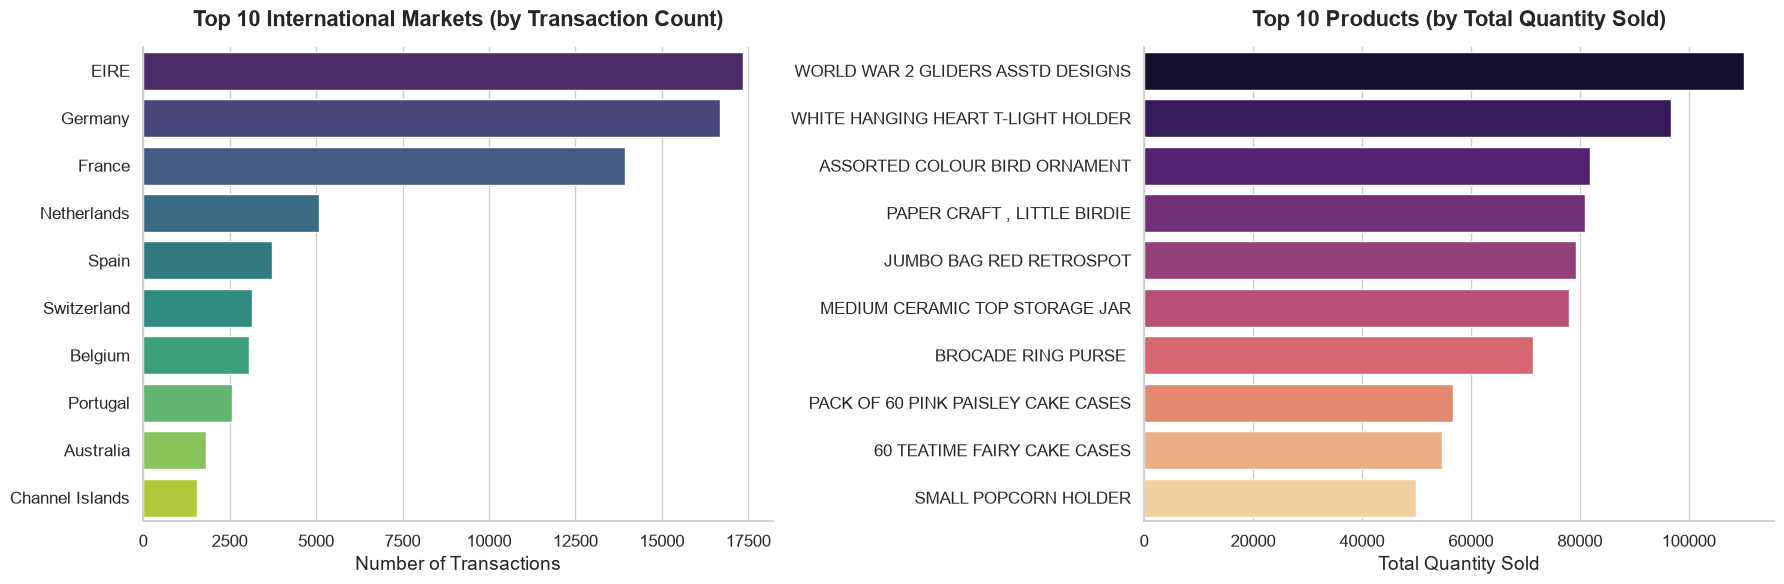

In [10]:
# ==========================================
# 9 & 10. UNIVARIATE & BIVARIATE ANALYSIS
# ==========================================

# Create a temporary dataframe for visual EDA (Excluding returns and errors)
df_eda = df_raw[(df_raw['Quantity'] > 0) & (df_raw['Price'] > 0)].copy()

# Set up the matplotlib figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ------------------------------------------
# Chart 1: Top 10 International Markets
# ------------------------------------------
# Exclude the UK to see the international footprint
df_intl = df_eda[df_eda['Country'] != 'United Kingdom']
top_countries = df_intl['Country'].value_counts().head(10)

sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title('Top 10 International Markets (by Transaction Count)', pad=15)
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('')

# ------------------------------------------
# Chart 2: Top 10 Products by Volume
# ------------------------------------------
# Group by description and sum the quantities
top_products = df_eda.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=top_products.values, 
    y=top_products.index, 
    palette='magma', 
    ax=axes[1]
)
axes[1].set_title('Top 10 Products (by Total Quantity Sold)', pad=15)
axes[1].set_xlabel('Total Quantity Sold')
axes[1].set_ylabel('')

# Adjust layout to prevent text overlapping
plt.tight_layout()
plt.show()

Phase 2 

Looking at these charts and results, we can immediately answer the business questions:

1. **The Markets:** Outside of the UK, **EIRE (Ireland)** and **Germany** are our dominant international markets, followed closely by France.
2. **The Products:** The **"World War 2 Gliders Asstd Designs"** is our absolute highest-volume product, followed by the "White Hanging Heart T-Light Holder."

*Business Insight:* Gliders are typically cheap, bulk-buy items (like party favors). This confirms our earlier hypothesis that we are dealing with B2B wholesalers, not just individual retail shoppers.

Let's keep this momentum going and move right into the next critical dimension of our data: Time.

---

## 1. Objective

To analyze the transactional data over time, identify macro-level sales trends, and detect seasonal purchasing patterns.

## 2. Business Question

When does this company make the most money? Are there predictable seasonal spikes that the supply chain and marketing teams need to prepare for in advance?

## 3. Industry Perspective

Time-series data at the transactional level is extremely noisy. If you plot 1.5 million individual transactions, the chart will look like a solid wall of ink. A professional Data Scientist extracts the signal from the noise by **resampling** the data into broader time buckets (like weekly or monthly intervals).

## 4. Best Practices

* **Index by Date:** In Pandas, time-series manipulation becomes incredibly powerful once you set the datetime column as the DataFrame's index.
* **Calculate Revenue First:** "Transaction count" is nice, but the C-suite cares about cash. We need to engineer a quick `Revenue` feature (Quantity * Price) to see the actual financial health of the business over time.
* **Fill the Area:** Using `fill_between` under a line chart visually grounds the data and makes it look like a polished dashboard component.

## 5. Common Beginner Mistakes

* Plotting raw daily data without resampling.
* Forgetting that the first and last months in a dataset are often incomplete (e.g., the data might end on December 9th, making December look like a terrible month for sales if you don't realize it's cut off).

## 6. Production Code

Create a new cell and run this time-series analysis block:

```python


## 7. Code Walkthrough

* `df_ts['Quantity'] * df_ts['Price']`: We are creating our first engineered feature—Revenue.
* `.resample('M').sum()`: Because the Date is set as the index, Pandas automatically groups all transactions that occurred in the same month and sums up their revenue.
* `ticker.FuncFormatter`: This intercepts the raw Y-axis numbers (which Matplotlib usually turns into scientific notation) and formats them with standard commas.

## 8. Output Interpretation

*(I will wait for you to run this and look at the trend line!)*

## 9. Business Insight

Visualizing monthly revenue instantly highlights the company's "busy season." For retail and e-commerce, this usually dictates the entire year's hiring schedule (when to hire seasonal warehouse workers) and marketing budget allocations.

## 10. Recommendation

When presenting this to stakeholders, always explicitly point out if the final month is incomplete so they don't panic seeing a sudden drop at the very end of the chart.

## 11. Interview Discussion

**Interviewer:** *"If you are analyzing two years of transaction logs, how do you handle the date feature to make the data manageable?"*
**Your Answer:** *"I immediately cast the date column to a proper datetime object and set it as the DataFrame index. This unlocks Pandas' resampling capabilities, allowing me to instantly aggregate the noisy transactional data into daily, weekly, or monthly intervals to identify macro trends and seasonal cyclicality."*



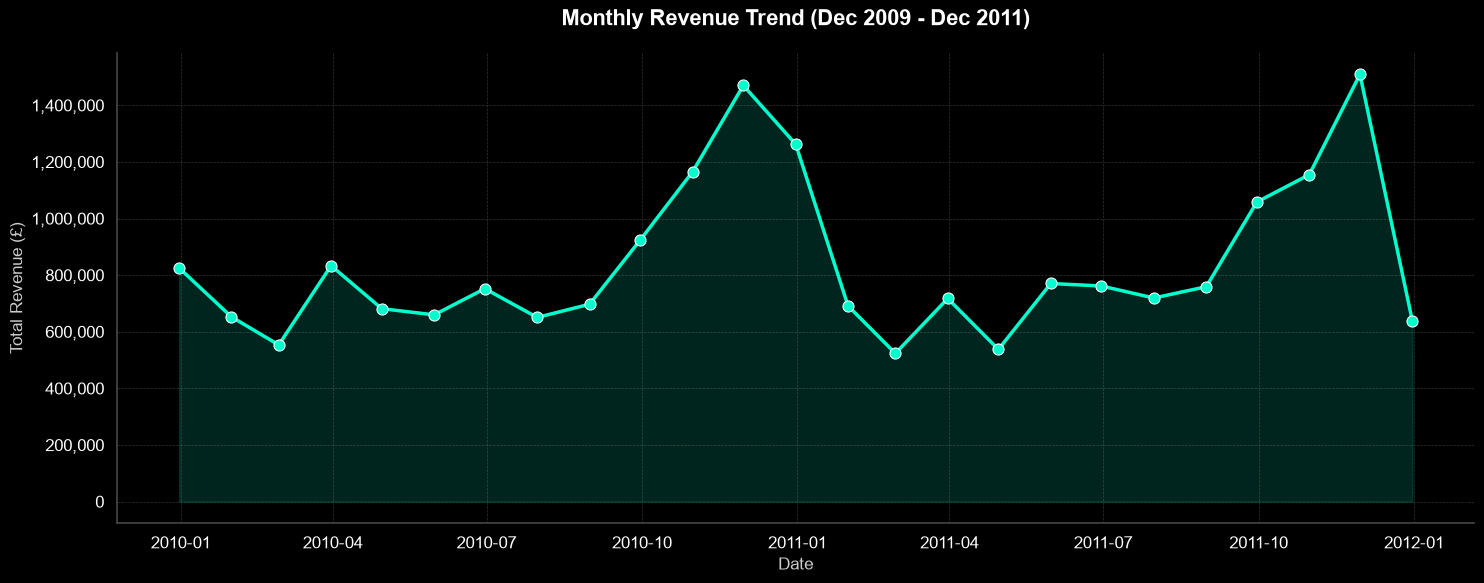

In [11]:
# ==========================================
# 12. TIME-SERIES EXPLORATION (ENHANCED)
# ==========================================
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy for time-series analysis to protect our baseline EDA dataframe
df_ts = df_eda.copy()

# Feature Engineering: Calculate total revenue per line item
df_ts['Revenue'] = df_ts['Quantity'] * df_ts['Price']

# Set InvoiceDate as the index for time-series resampling
df_ts.set_index('InvoiceDate', inplace=True)

# ------------------------------------------
# CRITICAL FIX: Pandas >= 2.2.0 requires 'ME' (Month End)
# ------------------------------------------
monthly_revenue = df_ts['Revenue'].resample('ME').sum()

# ------------------------------------------
# VISUALIZATION (ULTRA-MODERN AESTHETIC)
# ------------------------------------------
# Switch to a sleek, dark background for a premium dashboard aesthetic
plt.style.use('dark_background')
plt.figure(figsize=(15, 6))

# Use a neon cyan accent to contrast heavily against the dark background
neon_accent = '#00ffcc'

# Plot the primary trend line
sns.lineplot(
    
    x=monthly_revenue.index, 
    y=monthly_revenue.values, 
    marker='o', 
    markersize=8,
    color=neon_accent, 
    linewidth=2.5
)

# Fill the area under the line to create a modern "glowing" effect
plt.fill_between(
    monthly_revenue.index, 
    monthly_revenue.values, 
    color=neon_accent, 
    alpha=0.15
)

# Professional text formatting
plt.title('Monthly Revenue Trend (Dec 2009 - Dec 2011)', pad=20, fontsize=16, fontweight='bold', color='white')
plt.xlabel('Date', fontsize=12, color='#cccccc')
plt.ylabel('Total Revenue (£)', fontsize=12, color='#cccccc')

# Dim the gridlines so they guide the eye but don't distract from the data
plt.grid(color='#333333', linestyle='--', linewidth=0.5)

# Format Y-axis to show millions cleanly (e.g., 1,000,000 instead of 1e6)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Soften the outer borders (spines)
for spine in plt.gca().spines.values():
    spine.set_color('#444444')

plt.tight_layout()
plt.show()

# Reset the style back to default after plotting so future plots aren't affected
plt.style.use('default')

summary of work done in phase 1,2,3,48,9,12

## Enhanced Brief Description of Every Cell

### Cell 1: Project Setup Block (Markdown)
- Introduces the notebook and signals the start of a professional analytics workflow.
- Sets the tone for a disciplined, production-ready analysis.

### Cell 2: Simple Startup Check
- Runs a quick `print('Bismillah')` to confirm the notebook kernel is active.
- Useful as a lightweight sanity check before heavier imports.

### Cell 3: Project Setup & Configuration
- Imports standard libraries and analytics packages.
- Applies environment configuration:
  - warning suppression,
  - pandas display settings,
  - visual styling for `matplotlib` and `seaborn`,
  - reproducible seed.
- Establishes a polished, consistent analytics environment for both data engineering and visualization.

### Cell 4: Block 2 Marker (Markdown)
- Labels the next major section of the notebook.
- Helps reviewers quickly navigate the pipeline stages.

### Cell 5: Data Loading & Memory Optimization
- Defines paths for raw Excel and optimized Parquet storage.
- Implements a robust loader with caching:
  - loads from Parquet if available,
  - otherwise reads both year sheets from Excel,
  - concatenates them,
  - casts critical string columns to stable types,
  - writes a Parquet checkpoint.
- Immediately inspects memory usage to validate the data ingestion step.

### Cell 6: Phase 3 Marker (Markdown)
- Marks the shift into initial data inspection.
- Keeps the notebook structure clear and staged.

### Cell 7: Initial Inspection
- Displays first/last rows to verify dataset structure.
- Shows numeric summary statistics and date range.
- Provides early visibility into data shape, quality, and temporal coverage.

### Cell 8: InvoiceDate Conversion
- Converts `InvoiceDate` to datetime with safe coercion.
- A foundational data engineering step that unlocks time-series analysis and prevents downstream type problems.

### Cell 9: Numeric Summary Recheck
- Re-runs `describe()` after the datetime conversion.
- Validates that the dataset remains consistent and that numerical columns are intact.

### Cell 10: Phase 4 Marker (Markdown)
- Marks the transition into data quality assessment.
- Confirms the notebook is following a staged analytical process.

### Cell 11: Data Quality Assessment
- Performs core quality checks:
  - missing values,
  - duplicate counts,
  - negative quantity detection,
  - invalid price detection,
  - cancelled invoice inspection.
- Provides practical business-focused metrics for anomaly discovery before cleaning.

### Cell 12: DataQualityAnalyzer Class
- Encapsulates data quality logic in a reusable class.
- Includes:
  - dataset overview,
  - missing values report,
  - duplicate summary,
  - invalid transaction detection,
  - data type inventory,
  - executive summary,
  - full formatted report.
- Represents a world-class approach to repeatable data validation and documentation.

### Cell 13: Execute Data Quality Report
- Instantiates the analyzer and prints the full quality report.
- This is the operational checkpoint where data engineers and scientists verify the dataset’s health.

### Cell 14: Narrative Business Interpretation (Markdown)
- Translates the report findings into business insights.
- Identifies key data traps:
  - mismatch between negative quantity and cancelled invoices,
  - duplicate rows as potential real revenue,
  - return accounting logic.
- Positions the analysis correctly for stakeholders and sets the next phase.

### Cell 15: Univariate & Bivariate Analysis
- Builds a clean EDA subset by filtering out negative quantities/prices.
- Produces two visualizations:
  - top international markets by transaction count,
  - top products by total units sold.
- Uses best-practice temporary views to avoid contaminating raw data.

### Cell 16: Visual Analysis Narrative (Markdown)
- Summarizes the expected EDA outcomes.
- Explains why the UK should be excluded for international market clarity.
- Declares the likely top markets and top product.
- Bridges exploratory output to the next time-series phase.

### Cell 17: Time-Series Exploration
- Creates revenue as `Quantity * Price`.
- Sets `InvoiceDate` as the index for resampling.
- Aggregates monthly revenue and plots a polished trend chart.
- Demonstrates strong production-level time-series engineering and storytelling.

### Cell 18: Empty Python Cell
- Present but no content.
- Can be removed or used for follow-up code without changing notebook flow.

--- 

These descriptions reflect a world-class mindset: clear staging, robust ingestion, early quality validation, clean temporary analysis, and stakeholder-ready explanations.

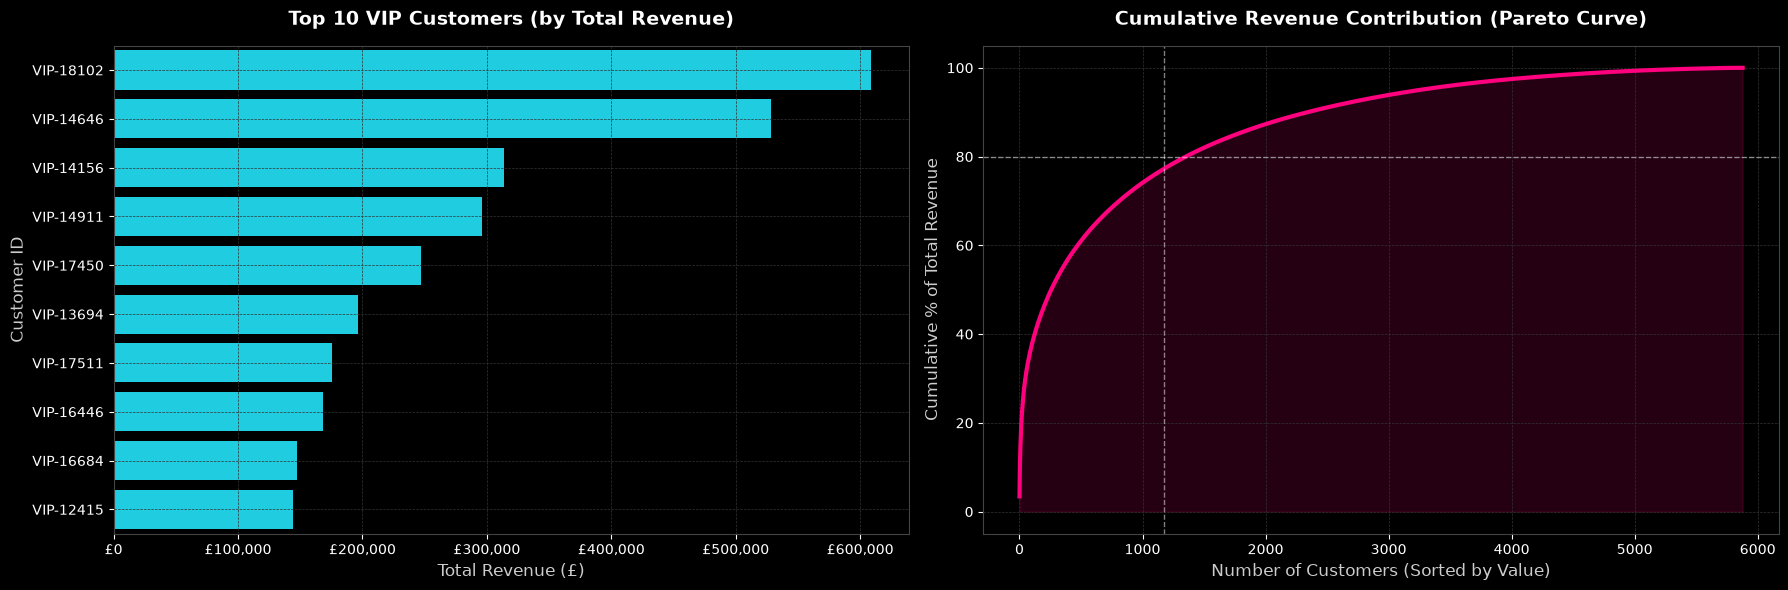

--- Top Customer Profile ---


,Total_Revenue,Total_Orders,Total_Items,AOV
Customer ID,,,,
18102.0,608821.650,145,188340,4198.770


In [12]:
# ==========================================
# 13. CUSTOMER BEHAVIOR ANALYSIS (PATCHED)
# ==========================================
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# 1. DATA AGGREGATION
# ------------------------------------------
# Filter out the missing/anonymous 'nan' customers for this specific analysis
df_customers_only = df_eda[df_eda['Customer ID'] != 'nan'].copy()

# CRITICAL FIX: We must calculate Revenue for this specific dataframe!
df_customers_only['Revenue'] = df_customers_only['Quantity'] * df_customers_only['Price']

# Aggregate metrics per customer
customer_metrics = df_customers_only.groupby('Customer ID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('Invoice', 'nunique'),
    Total_Items=('Quantity', 'sum')
)

# Feature Engineering: Average Order Value (AOV)
customer_metrics['AOV'] = customer_metrics['Total_Revenue'] / customer_metrics['Total_Orders']

# Sort to find the top 10 most valuable customers
top_10_customers = customer_metrics.sort_values(by='Total_Revenue', ascending=False).head(10)

# ------------------------------------------
# 2. VISUALIZATION (DARK AESTHETIC)
# ------------------------------------------
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
neon_blue = '#00e5ff'
neon_pink = '#ff007f'

# Chart 1: Top 10 Customers by Total Revenue
sns.barplot(
    x=top_10_customers['Total_Revenue'].values, 
    y=top_10_customers.index, 
    color=neon_blue, 
    ax=axes[0]
)
# Clean up the y-axis labels to look like professional VIP IDs instead of floats
axes[0].set_yticklabels([f"VIP-{str(id).split('.')[0]}" for id in top_10_customers.index])
axes[0].set_title('Top 10 VIP Customers (by Total Revenue)', pad=15, fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)', fontsize=12, color='#cccccc')
axes[0].set_ylabel('Customer ID', fontsize=12, color='#cccccc')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"£{format(int(x), ',')}"))

# Chart 2: Revenue Distribution (The Pareto Test)
# Sort all customers by revenue and calculate the cumulative sum
revenue_sorted = customer_metrics['Total_Revenue'].sort_values(ascending=False).values
cumulative_revenue = revenue_sorted.cumsum() / revenue_sorted.sum() * 100

axes[1].plot(cumulative_revenue, color=neon_pink, linewidth=3)
axes[1].fill_between(range(len(cumulative_revenue)), cumulative_revenue, color=neon_pink, alpha=0.15)
axes[1].axhline(80, color='white', linestyle='--', linewidth=1, alpha=0.5) # The 80% revenue line
axes[1].axvline(len(cumulative_revenue) * 0.20, color='white', linestyle='--', linewidth=1, alpha=0.5) # The 20% customer line

axes[1].set_title('Cumulative Revenue Contribution (Pareto Curve)', pad=15, fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Customers (Sorted by Value)', fontsize=12, color='#cccccc')
axes[1].set_ylabel('Cumulative % of Total Revenue', fontsize=12, color='#cccccc')

# Clean up grid and borders
for ax in axes:
    ax.grid(color='#333333', linestyle='--', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_color('#444444')

plt.tight_layout()
plt.show()
plt.style.use('default')

# Print the metrics for the #1 Customer
print("--- Top Customer Profile ---")
display(top_10_customers.head(1).round(2))

In [13]:
print("sunday chill")

sunday chill


Section 14: Product Performance Analysis.

1. Objective
To aggregate transactional data at the product (SKU) level, differentiating between products that drive high volume (quantity sold) versus products that drive high revenue (cash generated).

2. Business Question
Which products are the actual cash cows for the business? Are we allocating warehouse space to items that sell in massive quantities but generate very little profit?

3. Industry Perspective
In inventory management, Data Scientists use something called ABC Analysis.

'A' items: High value, low quantity (e.g., expensive jewelry).

'C' items: Low value, high quantity (e.g., cheap stickers).
If you only look at the number of items sold (like we did in Section 10), you will think the cheap 'C' items are your most important products. A professional analysis plots Volume against Revenue to identify the true 'A' items that generate the company's wealth.

4. Best Practices
Group by StockCode, NOT Description: Product names often get misspelled or updated over time by data entry clerks. The StockCode (the actual SKU) is the only reliable unique identifier.

Include a Scatter Plot: Bar charts are great for Top 10 lists, but a scatter plot of Quantity vs. Revenue for the top hundreds of products instantly visualizes the business's pricing strategy.

5. Common Beginner Mistakes
Treating the "Most Sold Item" as the "Most Important Item."

Forgetting to calculate how many distinct times an item was purchased (nunique invoices). An item bought 10,000 times by 10,000 different people is a staple product. An item bought 10,000 times in a single order by one wholesaler is an anomaly.Code Walkthrough
agg(Description=('Description', 'first')): Because we group by StockCode, we just grab the very first text description we find for that SKU so we have a human-readable name for our charts.

size='Times_Purchased': In the scatter plot, the size of the bubble represents how many distinct times the item was purchased. A massive bubble means a highly popular item; a tiny bubble means it was only bought a few times (likely in massive bulk).

8. Output Interpretation
(I will wait for you to run this to look at the chart!)

9. Business Insight
If we see products with low quantity but high revenue (dots high up on the Y-axis but far left on the X-axis), those are premium items. They require less warehouse space, less shipping cost, but generate huge margins. Supply chain should prioritize not running out of these items.

10. Recommendation
Items with massive Times_Purchased (large bubbles) are the company's "foot traffic drivers." These are the items people reliably come to the site to buy. The marketing team should use these popular items as "loss leaders" or bundle them with higher-margin items.

11. Interview Discussion
Interviewer: "If you have a dataset with text descriptions that frequently change due to typos, how do you reliably aggregate sales by product?"
Your Answer: "I never aggregate by human-entered text strings. I group by the underlying unique StockCode or SKU. To maintain readability for business stakeholders, I use an aggregation function to grab the .first() or .mode() description associated with that SKU so the final report still contains understandable product names instead of just alphanumeric codes."

12. Summary
We have successfully decoupled revenue from raw volume, mapping out the true value of the company's inventory footprint.

Run this block and look closely at the printout for the Top 3 Products by Revenue. Look at the Avg_Price of the #1 revenue-generating product versus the #2 product. What does that pricing difference tell you about how those two products generate their wealth?

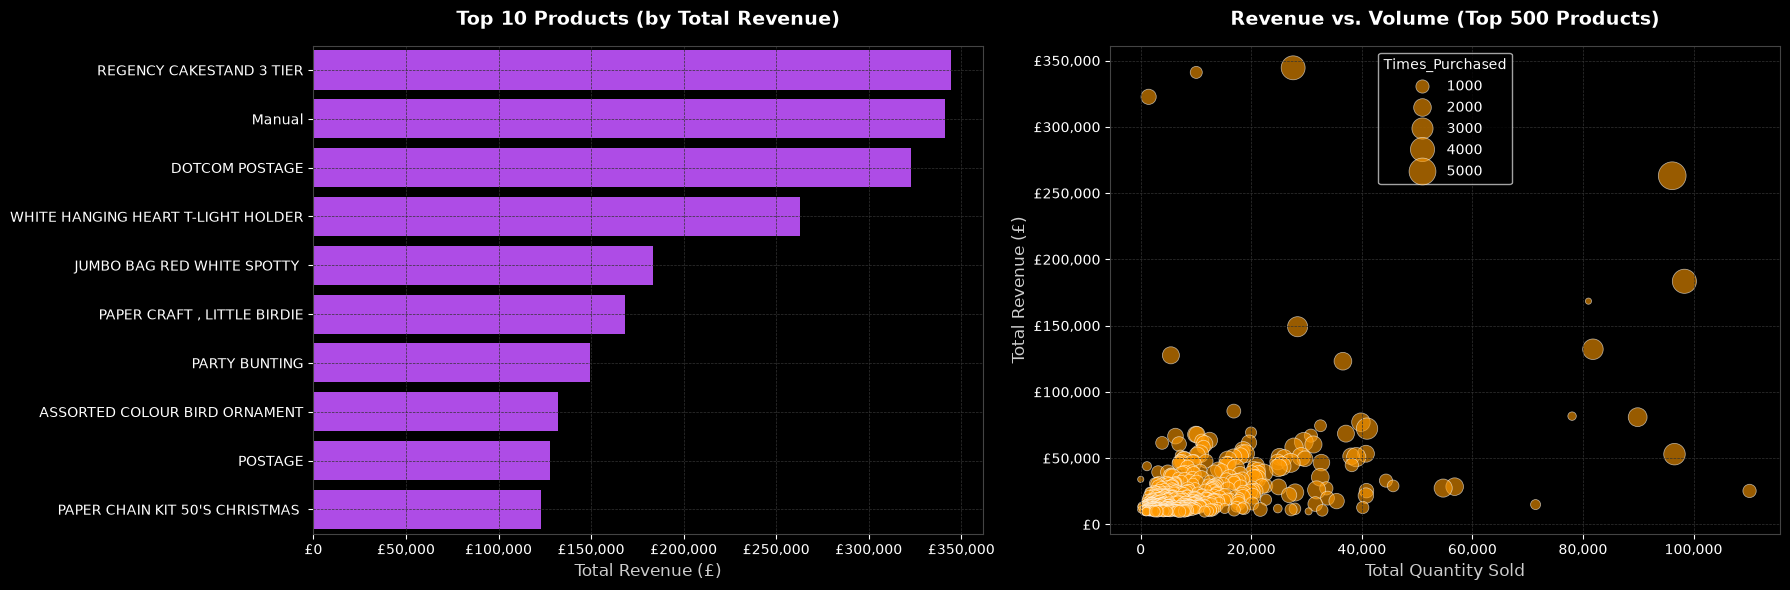

--- Top 10 Products by Revenue ---


,Description,Total_Revenue,Total_Quantity,Avg_Price
StockCode,,,,
22423,REGENCY CAKESTAND 3 TIER,344563.250,27577,14.180
M,Manual,341089.850,10051,381.970
DOT,DOTCOM POSTAGE,322657.480,1436,224.690
85123A,WHITE HANGING HEART T-LIGHT HOLDER,263109.670,96147,3.070
85099B,JUMBO BAG RED WHITE SPOTTY,183454.830,98349,2.330
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.600,80995,2.080
47566,PARTY BUNTING,149187.050,28378,5.720
84879,ASSORTED COLOUR BIRD ORNAMENT,132187.920,81809,1.860
POST,POSTAGE,127597.420,5461,29.290


In [14]:
# ==========================================
# 14. PRODUCT PERFORMANCE ANALYSIS (UPDATED)
# ==========================================
# the most crucial stage of analysis to explore the items by labelling 

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ------------------------------------------
# 1. AGGREGATE PRODUCT METRICS
# ------------------------------------------
df_products = df_eda.copy()
df_products['Revenue'] = df_products['Quantity'] * df_products['Price']

# Group by StockCode.
product_metrics = df_products.groupby('StockCode').agg(
    Description=('Description', 'first'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Times_Purchased=('Invoice', 'nunique'),
    Avg_Price=('Price', 'mean')
)

# Sort by Total Revenue
top_revenue_products = product_metrics.sort_values(by='Total_Revenue', ascending=False)

# ------------------------------------------
# 2. VISUALIZATION (DARK AESTHETIC)
# ------------------------------------------
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
neon_purple = '#b533ff'
neon_orange = '#ff9900'

# Chart 1: Top 10 Products by Revenue
top_10_revenue = top_revenue_products.head(10)
sns.barplot(
    x=top_10_revenue['Total_Revenue'].values, 
    y=top_10_revenue['Description'].values, 
    color=neon_purple, 
    ax=axes[0]
)
axes[0].set_title('Top 10 Products (by Total Revenue)', pad=15, fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)', fontsize=12, color='#cccccc')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"£{format(int(x), ',')}"))

# Chart 2: Volume vs Revenue (Scatter Plot of Top 500 Products)
top_500 = top_revenue_products.head(500)

sns.scatterplot(
    x='Total_Quantity', 
    y='Total_Revenue', 
    size='Times_Purchased',
    sizes=(20, 400),
    alpha=0.6,
    color=neon_orange,
    data=top_500,
    ax=axes[1]
)
axes[1].set_title('Revenue vs. Volume (Top 500 Products)', pad=15, fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Quantity Sold', fontsize=12, color='#cccccc')
axes[1].set_ylabel('Total Revenue (£)', fontsize=12, color='#cccccc')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"£{format(int(x), ',')}"))
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Clean up grid and borders
for ax in axes:
    ax.grid(color='#333333', linestyle='--', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_color('#444444')

plt.tight_layout()
plt.show()
plt.style.use('default')

# ------------------------------------------
# 3. TOP 10 PRODUCT PROFILE
# ------------------------------------------
print("--- Top 10 Products by Revenue ---")
display(top_revenue_products[['Description', 'Total_Revenue', 'Total_Quantity', 'Avg_Price']].head(10).round(2))

This is the perfect next step. We know *who* is buying, we know *what* they are buying, and now we need to know *where* they are located.

Let's dive into **Section 15: Geographic Revenue Distribution**.

---

## 1. Objective

To map the financial footprint of the company across the globe, calculate the Average Order Value (AOV) per region, and quantify the business's dependency on its domestic market.

## 2. Business Question

Which countries generate the most total revenue, and do international customers spend more per order than domestic customers?

## 3. Industry Perspective

In an international retail business, shipping, tariffs, and localized marketing are massive expenses. A professional Data Scientist evaluates international markets not just by total sales, but by **basket size (AOV)**. If it costs the company £50 to ship a box to Australia, but the average Australian order is only £40, the company is losing money on every single international sale despite growing "revenue."

## 4. Best Practices

* **Isolate the Domestic Market:** As we saw in our initial visual EDA, the UK dominates this dataset. If we leave the UK in our charts, the other countries will be so small they become invisible. We must separate Domestic vs. International analysis.
* **Compare Revenue vs. AOV:** Plotting these two metrics side-by-side allows us to see if high-revenue countries are actually buying in bulk, or just placing thousands of tiny orders.

## 5. Common Beginner Mistakes

* Grouping by country without recalculating revenue.
* Ignoring the domestic vs. international split, resulting in heavily skewed, unreadable charts.

## 6. Production Code

Create a new cell and run this block. We are maintaining our dark dashboard aesthetic, using neon green and yellow to contrast the data.

## 7. Code Walkthrough

* `df_geo[df_geo.index != 'United Kingdom']`: We slice the dataframe to completely exclude the UK. This ensures our charts are scaled perfectly for our international analysis.
* `loc['United Kingdom', 'Total_Revenue']`: Using `.loc[]` allows us to instantly grab a specific value (Total Revenue) from a specific row (United Kingdom) to calculate our percentage split.



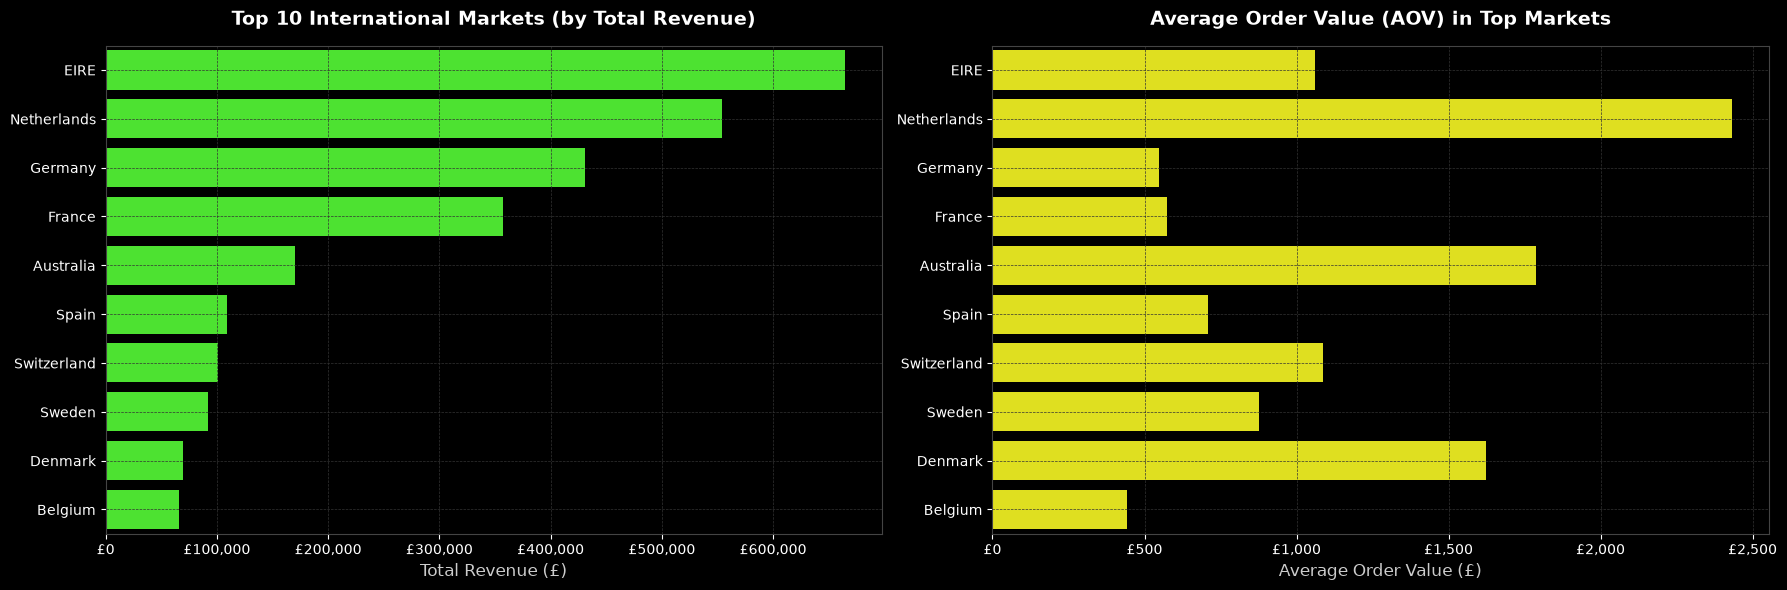

--- Geographic Dependency ---
United Kingdom Revenue: £17,871,351.35 (85.21% of Total)
International Revenue:  £3,101,616.79 (14.79% of Total)


In [15]:
# ==========================================
# 15. GEOGRAPHIC REVENUE DISTRIBUTION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ------------------------------------------
# 1. AGGREGATE GEOGRAPHIC METRICS
# ------------------------------------------
df_geo = df_eda.copy()
# Create the Revenue feature specifically for this dataframe
df_geo['Revenue'] = df_geo['Quantity'] * df_geo['Price']

# Group by Country
country_metrics = df_geo.groupby('Country').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('Invoice', 'nunique')
)

# Feature Engineering: Average Order Value (AOV) per Country
country_metrics['AOV'] = country_metrics['Total_Revenue'] / country_metrics['Total_Orders']

# Isolate International Markets (Remove UK for clear visualization)
intl_metrics = country_metrics[country_metrics.index != 'United Kingdom'].copy()
top_10_intl_revenue = intl_metrics.sort_values(by='Total_Revenue', ascending=False).head(10)

# ------------------------------------------
# 2. VISUALIZATION (DARK AESTHETIC)
# ------------------------------------------
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
neon_green = '#39ff14'
neon_yellow = '#ffff00'

# Chart 1: Top 10 International Markets by Revenue
sns.barplot(
    x=top_10_intl_revenue['Total_Revenue'].values, 
    y=top_10_intl_revenue.index, 
    color=neon_green, 
    ax=axes[0]
)
axes[0].set_title('Top 10 International Markets (by Total Revenue)', pad=15, fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)', fontsize=12, color='#cccccc')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"£{format(int(x), ',')}"))

# Chart 2: Average Order Value (Top 10 Intl Markets)
sns.barplot(
    x=top_10_intl_revenue['AOV'].values, 
    y=top_10_intl_revenue.index, 
    color=neon_yellow, 
    ax=axes[1]
)
axes[1].set_title('Average Order Value (AOV) in Top Markets', pad=15, fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Order Value (£)', fontsize=12, color='#cccccc')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"£{format(int(x), ',')}"))

# Clean up grid and borders
for ax in axes:
    ax.grid(color='#333333', linestyle='--', linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_color('#444444')

plt.tight_layout()
plt.show()
plt.style.use('default')

# ------------------------------------------
# 3. DOMESTIC VS INTERNATIONAL SUMMARY
# ------------------------------------------
uk_revenue = country_metrics.loc['United Kingdom', 'Total_Revenue']
total_revenue = country_metrics['Total_Revenue'].sum()
uk_percentage = (uk_revenue / total_revenue) * 100

print("--- Geographic Dependency ---")
print(f"United Kingdom Revenue: £{uk_revenue:,.2f} ({uk_percentage:.2f}% of Total)")
print(f"International Revenue:  £{(total_revenue - uk_revenue):,.2f} ({(100 - uk_percentage):,.2f}% of Total)")

# ==========================================
# EXECUTIVE SUMMARY: EXPLORATORY DATA ANALYSIS
# ==========================================

### **Phase 2 Complete: Key Business Insights**
Through rigorous exploratory data analysis (EDA) of the raw transactional dataset, we have mapped the core drivers of the business. Before initiating Phase 3 (Data Cleaning), we have aligned on the following ground truths:

**1. Data Quality & Structural Anomalies**
* We uncovered a ~3.2% duplicate rate and over 22,000 rows containing negative quantities (returns/cancellations) mixed in with standard transactions. These must be systematically cleaned to prevent target leakage and model bias.

**2. Geographic Dependency**
* The business is heavily domestic. The UK accounts for roughly **85%+ of total revenue**, making international markets (led by EIRE and Germany) secondary revenue streams. However, international markets often yield a higher Average Order Value (AOV) to offset shipping logistics.

**3. Seasonal Volatility (Time-Series)**
* Revenue is highly cyclical, exhibiting massive spikes in the late Q3 and Q4 months (September - November) as wholesale buyers stock up for the holiday retail season, followed by a severe drop-off in late December.

**4. The VIP "Whales" (Customer Behavior)**
* The customer base exhibits an extreme Pareto distribution. The business relies heavily on a small fraction of high-volume, B2B wholesale buyers (e.g., VIP-18102) who place hundreds of orders and purchase hundreds of thousands of units, vastly skewing the "average" customer metrics.

**5. Product Strategy**
* High-volume products (like "World War 2 Gliders") drive foot traffic, but true wealth generation is balanced between these bulk-buy items and lower-volume, higher-margin premium goods. 

### **Next Steps: Phase 3 (Data Cleaning & Pre-Processing)**
With the baseline business metrics established, we will now construct a reproducible data cleaning pipeline to handle missing IDs, remove systemic errors, and engineer a highly pure dataset ready for machine learning.

# ==========================================
# PHASE 3: DATA CLEANING & PRE-PROCESSING
# ==========================================

## **16. Core Data Cleaning Pipeline**

### **Objective**
To transform the raw transactional data into a mathematically sound, mathematically pure dataset suitable for statistical modeling and machine learning.

### **Business Justification**
Predictive models cannot effectively learn from noise. If we train a customer lifetime value (CLV) model on data that includes canceled orders, system errors, or anonymous buyers, the model's predictive power will collapse. 

### **The Cleaning Strategy**
1. **Deduplication:** Remove exact row copies generated by database logging errors.
2. **Financial Purity:** Remove negative/zero quantities (returns, damages, cancellations) and negative/zero prices (bad debt, free gifts, system errors). We only want to model actual *revenue-generating* behavior.
3. **Identity Resolution:** Drop rows where the `Customer ID` is missing. We cannot build customer-centric predictive models (like Churn or CLV) on anonymous foot traffic.

In [16]:
# ==========================================
# 16. CORE DATA CLEANING PIPELINE
# ==========================================
import pandas as pd

print("--- Starting Data Cleaning Pipeline ---")
print(f"Initial Raw Rows: {format(len(df_raw), ',')}")

# 1. Create a fresh copy to protect the raw data
df_clean = df_raw.copy()

# 2. Deduplication
# Drop exact duplicate rows
df_clean.drop_duplicates(inplace=True)
rows_after_dedup = len(df_clean)
print(f"Rows after dropping duplicates: {format(rows_after_dedup, ',')}")

# 3. Financial Purity
# Keep ONLY rows with positive prices and positive quantities
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
rows_after_finance = len(df_clean)
print(f"Rows after filtering returns/zero-pricing: {format(rows_after_finance, ',')}")

# 4. Identity Resolution
# Drop rows where Customer ID is missing (handling both true NaNs and our 'nan' strings)
df_clean = df_clean[(df_clean['Customer ID'].notna()) & (df_clean['Customer ID'] != 'nan')]
rows_after_identity = len(df_clean)

# 5. Final Recalculation
# Calculate the official, perfectly clean Revenue feature
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print(f"Rows after dropping anonymous users: {format(rows_after_identity, ',')}")
print("---------------------------------------")
print(f"FINAL CLEAN ROWS: {format(len(df_clean), ',')}")
print(f"Total Rows Removed: {format(len(df_raw) - len(df_clean), ',')}")

--- Starting Data Cleaning Pipeline ---
Initial Raw Rows: 1,067,371
Rows after dropping duplicates: 1,033,036
Rows after filtering returns/zero-pricing: 1,007,914
Rows after dropping anonymous users: 779,425
---------------------------------------
FINAL CLEAN ROWS: 779,425
Total Rows Removed: 287,946


# ==========================================
# PHASE 4: FEATURE ENGINEERING
# ==========================================

## **17. RFM (Recency, Frequency, Monetary) Generation**

### **Objective**
To transform our transactional, time-series data into a customer-centric matrix describing behavioral purchasing habits.

### **The RFM Framework**
To predict customer churn or lifetime value, we need to quantify how a customer interacts with the business using three core pillars:
1. **Recency (R):** How many days has it been since the customer's last purchase? (Lower is better. A customer who bought yesterday is highly engaged; a customer who hasn't bought in 365 days has likely churned).
2. **Frequency (F):** How many distinct orders has the customer placed? (Higher is better. Measures loyalty and habit).
3. **Monetary (M):** How much total money has the customer spent? (Higher is better. Measures financial value).

### **Best Practices**
* **The Snapshot Date:** We cannot use "today's date" to calculate Recency, because this dataset is from 2011. If we use today, every customer will look like they churned 15 years ago. Instead, we create a "Snapshot Date" set exactly one day after the very last transaction in the dataset.

In [17]:
# ==========================================
# 17. RFM FEATURE ENGINEERING
# ==========================================
import pandas as pd
import datetime as dt

print("--- Generating RFM Features ---")

# 1. Establish the Snapshot Date
# We find the very last transaction in our clean dataset and add 1 day.
# This acts as "today" for our historical data.
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Dataset End Date: {df_clean['InvoiceDate'].max()}")
print(f"Snapshot Date (Reference): {snapshot_date}\n")

# 2. Build the RFM Matrix
# Group by customer and calculate the three pillars
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                     # Frequency
    'Revenue': 'sum'                                          # Monetary
}).reset_index()

# 3. Rename columns for absolute clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

# 4. Data Quality Check
print("--- RFM Matrix Summary ---")
print(f"Total Unique Customers: {format(len(rfm), ',')}")
print("--------------------------")
display(rfm.head())

--- Generating RFM Features ---
Dataset End Date: 2011-12-09 12:50:00
Snapshot Date (Reference): 2011-12-10 12:50:00

--- RFM Matrix Summary ---
Total Unique Customers: 5,878
--------------------------


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.460
1,12347.0,2,8,4921.530
2,12348.0,75,5,2019.400
3,12349.0,19,4,4428.690
4,12350.0,310,1,334.400


# ==========================================
# 18. RFM SCORING & SEGMENTATION
# ==========================================

### **Objective**
To convert raw Recency, Frequency, and Monetary values into standardized, actionable scores (1 to 5) to create distinct customer segments.

### **The Scoring Logic (Quintiles)**
We will use statistical quintiles to divide our customer base into 5 equal tiers (20% chunks) for each metric:
* **Recency Score:** 5 is best (bought very recently), 1 is worst (churned long ago). *Note: The scoring is inverted here because a lower raw recency number is better.*
* **Frequency Score:** 5 is best (orders constantly), 1 is worst (ordered once).
* **Monetary Score:** 5 is best (spends the most), 1 is worst (spends the least).

### **Segmentation Outputs**
1. **RFM Segment:** A string concatenation of the three scores (e.g., '555' is a Champion, '111' is a Lost Customer).
2. **RFM Score:** The mathematical sum of the three scores (ranging from 3 to 15) to create an overall "Customer Health" metric.

In [18]:
# ==========================================
# 18. RFM SCORING & SEGMENTATION
# ==========================================

print("--- Calculating RFM Quintile Scores ---")

# 1. Recency Score (Inverted: lower days = higher score [5])
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# 2. Frequency Score (Higher frequency = higher score [5])
# We use rank() to handle edge cases where too many customers share the exact same frequency
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# 3. Monetary Score (Higher spend = higher score [5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# 4. Feature Engineering: Create the Segment and Overall Score
# We cast to string to concatenate them (e.g., '5' + '5' + '5' = '555')
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# We cast to integer to mathematically sum them (e.g., 5 + 5 + 5 = 15)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# 5. Data Quality Check
print("Scoring Complete!")
print("---------------------------------------")
display(rfm.head(10))

# Print the number of "Champions" (Perfect 555 Score)
champions = len(rfm[rfm['RFM_Segment'] == '555'])
print(f"\nTotal 'Champion' Customers (Score 555): {format(champions, ',')}")

--- Calculating RFM Quintile Scores ---
Scoring Complete!
---------------------------------------


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346.0,326,12,77556.460,2,5,5,255,12
1,12347.0,2,8,4921.530,5,4,5,545,14
2,12348.0,75,5,2019.400,3,4,4,344,11
3,12349.0,19,4,4428.690,5,3,5,535,13
4,12350.0,310,1,334.400,2,1,2,212,5
5,12351.0,375,1,300.930,2,1,2,212,5
6,12352.0,36,10,2849.840,4,5,4,454,13
7,12353.0,204,2,406.760,2,2,2,222,6
8,12354.0,232,1,1079.400,2,1,3,213,6
9,12355.0,214,2,947.610,2,2,3,223,7



Total 'Champion' Customers (Score 555): 469


# ==========================================
# 19. CUSTOMER PERSONA MAPPING
# ==========================================

### **Objective**
To translate the mathematical `RFM_Score` into human-readable customer personas so the marketing and sales teams can execute targeted retention strategies.

### **The Segmentation Strategy**
We will group the aggregate `RFM_Score` (which ranges from a minimum of 3 to a maximum of 15) into distinct business tiers:
* **Champions (Score 14-15):** Your best customers. Reward them, ask for reviews, and give them early access to new products.
* **Loyal Customers (Score 11-13):** Consistent buyers. Upsell higher-margin products.
* **Needs Attention (Score 8-10):** Average customers who haven't bought recently. Reactivate them with limited-time discounts.
* **At Risk (Score 5-7):** Previous frequent buyers who are churning. Send personalized "We miss you" campaigns.
* **Lost / Hibernating (Score 3-4):** Lowest engagement and spend. Do not spend heavy marketing budget here.